In [1]:
import numpy as np
import matplotlib.pyplot as plt

from svm_primal import PrimalSVM
from svm_dual import DualSVM
from kernels import linear_kernel, make_rbf_kernel, make_polynomial_kernel, make_laplacian_kernel
from utils import *

try:
	import scienceplots
	plt.style.use('science')
except ImportError:
    print("scienceplots not found, using default matplotlib style.")
    plt.style.use('default')

In [2]:
max_iter = 1000

# Example usage for both models (uses test_linear function)
X, y = make_toy_data(n=100, random_state=42)

Training Primal SVM (linear)...
Iter 0, Obj=69.3147, GradNorm=194.9760, lr=0.0010, w=[0.1295 0.1457], b=0.00000000, grad_w=[-129.5117 -145.7476], grad_b=0.0000
Iter 1000, Obj=16.8542, GradNorm=1.3970, lr=0.0010, w=[0.7102 0.7036], b=-0.00300000, grad_w=[-0.69    0.6895], grad_b=-1.0000
Finished subgradient descent.
Final objective value: 16.8542, w=[0.7102 0.7036], b=-0.003000
Primal SVM accuracy: 1.0000
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]


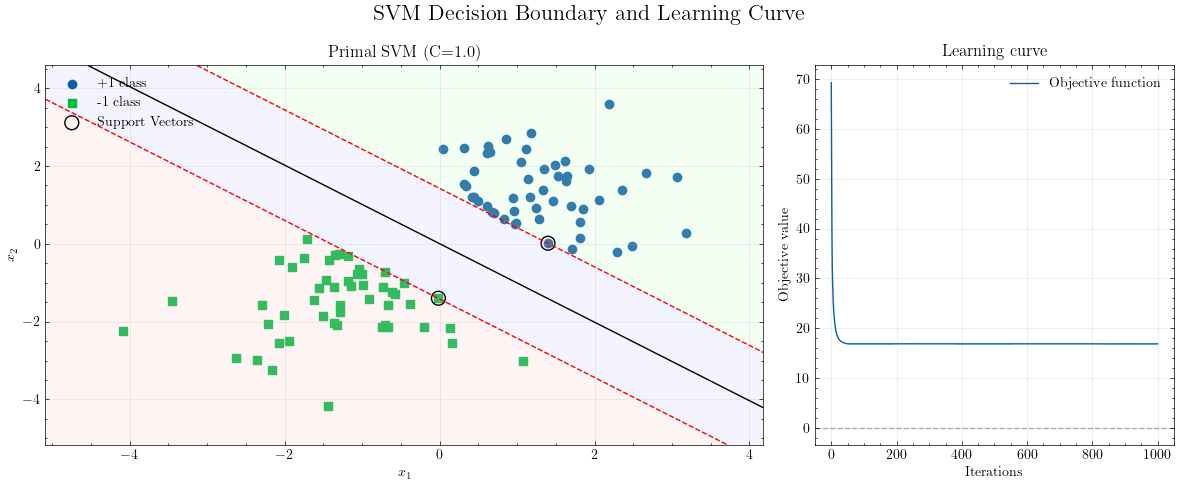

b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
Number of support vectors: 2
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
Support vectors: [ 8 70]
Number of X: 100


In [3]:
# Linear SVM - primal formulation
print("Training Primal SVM (linear)...")
primal_model = PrimalSVM(C=1.00, max_iter=max_iter, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True)
primal_model.fit(X, y)
primal_accuracy = primal_model.score(X, y)
print(f"Primal SVM accuracy: {primal_accuracy:.4f}")
plot_decision_boundary_2D(primal_model, X, y, title=f"Primal SVM (C={primal_model.C})",save_path="../figures/primal_svm.png")
primal_model.get_support_vectors()
print(f"Number of support vectors: {len(primal_model.get_support_vectors())}")
print(f"Support vectors: {primal_model.get_support_vectors()}")
print(f"Number of X: {len(X)}")

Training Primal SVM (linear) with Smooth Hinge loss...
Iter 0, Obj=100.0000, GradNorm=194.9760, lr=0.0010, w=[0.1295 0.1457], b=0.00000000, grad_w=[-129.5117 -145.7476], grad_b=0.0000
Iter 1000, Obj=0.5004, GradNorm=1.3970, lr=0.0010, w=[0.7102 0.7036], b=-0.00300000, grad_w=[-0.69    0.6895], grad_b=-1.0000
Finished subgradient descent.
Final objective value: 0.5004, w=[0.7102 0.7036], b=-0.003000
Primal SVM accuracy: 1.0000
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]


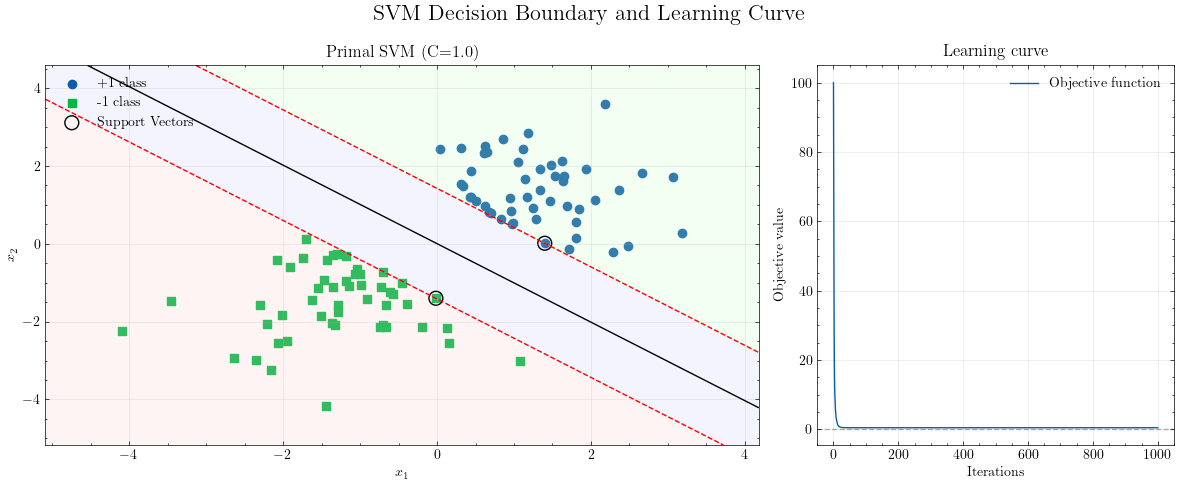

b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
Number of support vectors: 2
b: -0.003000000000000001, w: [0.71016491 0.7035567 ]
Support vectors: [ 8 70]
Number of X: 100


In [4]:
# Linear SVM - primal formulation
print("Training Primal SVM (linear) with Smooth Hinge loss...")
primal_model = PrimalSVM(C=1.00, max_iter=max_iter, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True, use_smooth=False)
primal_model.fit(X, y)
primal_accuracy = primal_model.score(X, y)
print(f"Primal SVM accuracy: {primal_accuracy:.4f}")
plot_decision_boundary_2D(primal_model, X, y, title=f"Primal SVM (C={primal_model.C})",save_path="../figures/primal_svm.png")

primal_model.get_support_vectors()
print(f"Number of support vectors: {len(primal_model.get_support_vectors())}")
print(f"Support vectors: {primal_model.get_support_vectors()}")
primal_model.b
print(f"Number of X: {len(X)}")


Training Dual SVM (linear)...
Iteration 0: obj=-0.1315, ||g||=10.0000, step=0.0026
Iteration 100: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 200: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 300: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 400: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 500: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 600: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 700: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 800: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 900: obj=-0.5000, ||g||=12.4044, step=0.0100
Iteration 1000: obj=-0.5000, ||g||=12.4044, step=0.0100
Dual SVM accuracy: 1.0000


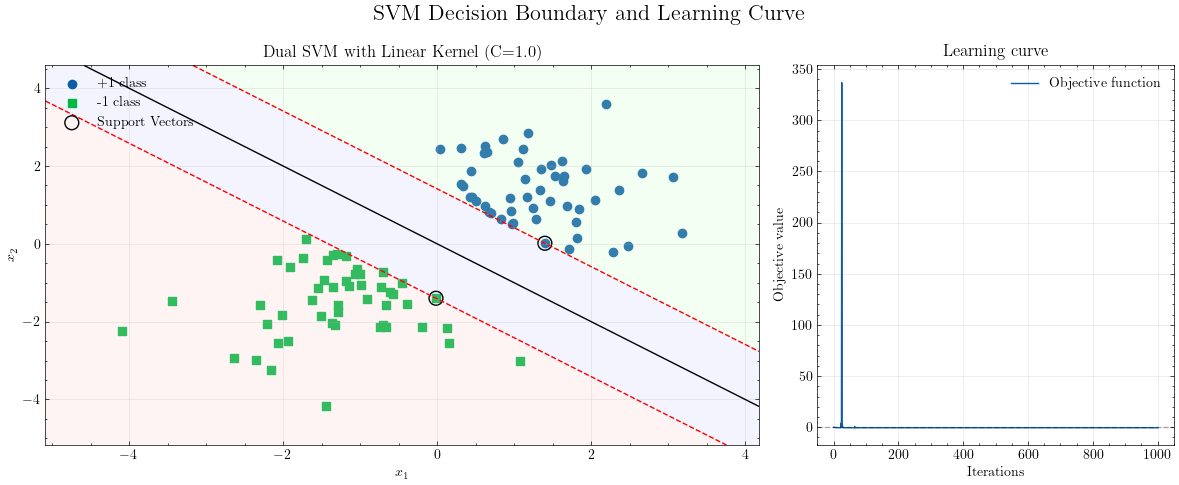

array([0.70710678, 0.70710678])

In [5]:
# Linear SVM - dual formulation
print("\nTraining Dual SVM (linear)...")
dual_model = DualSVM(C=1.0, max_iter=max_iter, tol=1e-12, use_line_search = True, bb_steps=True, verbose=True)
dual_model.fit(X, y)
dual_accuracy = dual_model.score(X, y)
print(f"Dual SVM accuracy: {dual_accuracy:.4f}")
plot_decision_boundary_2D(dual_model, X, y, title=f"Dual SVM with Linear Kernel (C={dual_model.C})",save_path="../figures/dual_svm.png")
dual_model.recover_w()


Training Dual SVM (RBF kernel)...
Iteration 0: obj=-0.8920, ||g||=10.0000, step=0.0463
Iteration 100: obj=-4.6328, ||g||=1.4037, step=0.3010
Iteration 200: obj=-4.6332, ||g||=1.4324, step=0.3783
Iteration 300: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 400: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 500: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 600: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 700: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 800: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 900: obj=-4.6332, ||g||=1.4325, step=0.0100
Iteration 1000: obj=-4.6332, ||g||=1.4325, step=0.0100
RBF Kernel SVM accuracy: 1.0000


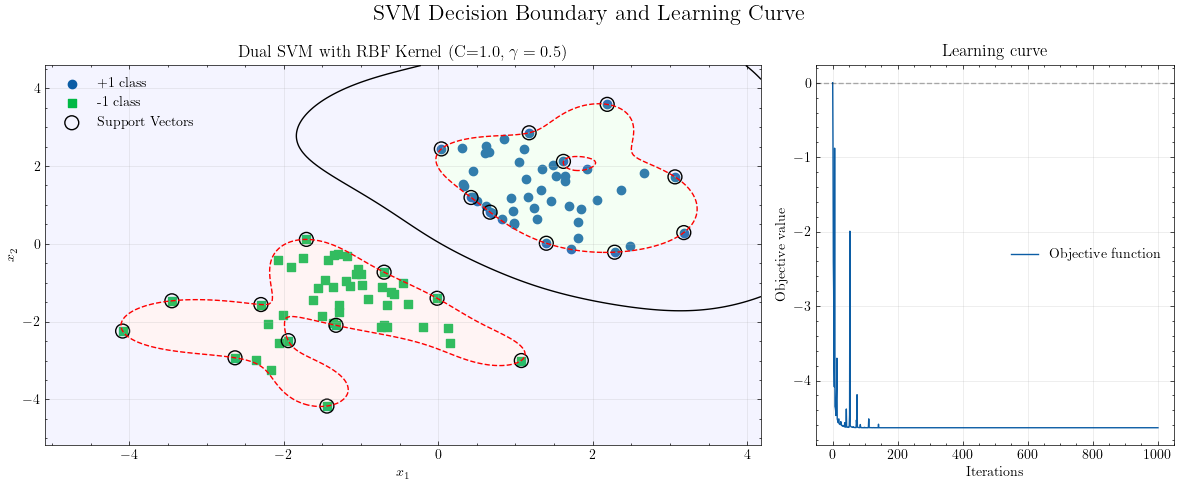

In [6]:

# Now try with an RBF kernel (non-linear)
print("\nTraining Dual SVM (RBF kernel)...")
rbf_kernel = make_rbf_kernel(gamma=0.5)
rbf_model = DualSVM(C=1.0, max_iter=max_iter, tol=1e-12, kernel=rbf_kernel, use_line_search = True, bb_steps=True, verbose=True)
rbf_model.fit(X, y)
rbf_accuracy = rbf_model.score(X, y)
print(f"RBF Kernel SVM accuracy: {rbf_accuracy:.4f}")
plot_decision_boundary_2D(rbf_model, X, y, title=f"Dual SVM with RBF Kernel (C={rbf_model.C}, $\\gamma=0.5$)",save_path="../figures/dual_svm_rbf.png")

Iter 0, Obj=6.9315, GradNorm=19.4976, lr=0.0010, w=[0.013  0.0146], b=0.00000000, grad_w=[-12.9512 -14.5748], grad_b=0.0000
Iter 1000, Obj=2.2874, GradNorm=0.0868, lr=0.0010, w=[0.6735 0.6063], b=0.03750000, grad_w=[0.0779 0.0382], grad_b=0.0000
Iter 2000, Obj=2.2946, GradNorm=0.1120, lr=0.0010, w=[0.6758 0.5995], b=0.03870000, grad_w=[-0.0502  0.005 ], grad_b=0.1000
Iter 3000, Obj=2.2974, GradNorm=0.0860, lr=0.0010, w=[0.6766 0.597 ], b=0.03910000, grad_w=[0.081  0.0289], grad_b=0.0000
Iter 4000, Obj=2.2985, GradNorm=0.1547, lr=0.0010, w=[0.677 0.596], b=0.03930000, grad_w=[-0.1469 -0.0486], grad_b=0.0000
Iter 5000, Obj=2.2988, GradNorm=0.0860, lr=0.0010, w=[0.677  0.5956], b=0.03940000, grad_w=[0.0814 0.0275], grad_b=0.0000
Iter 6000, Obj=2.2990, GradNorm=0.1547, lr=0.0010, w=[0.6772 0.5955], b=0.03940000, grad_w=[-0.1467 -0.0491], grad_b=0.0000
Iter 7000, Obj=2.2990, GradNorm=0.1113, lr=0.0010, w=[0.6772 0.5955], b=0.03940000, grad_w=[-0.0488  0.0009], grad_b=0.1000
Iter 8000, Obj=2

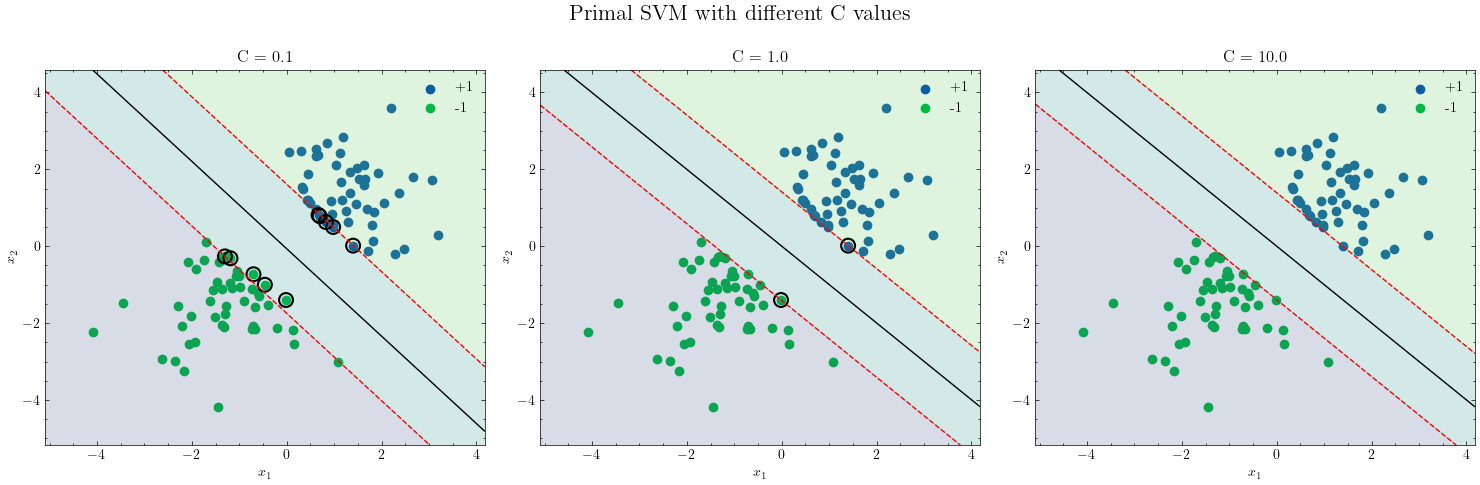

In [19]:
# Let's compare with different C values
C_values = [0.1, 1.0, 10.0]
plt.figure(figsize=(15, 5))

for i, C in enumerate(C_values):
    
    model = PrimalSVM(C=C, max_iter=100_000, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True)
    model.fit(X, y)
    plt.subplot(1, 3, i+1)
    plt.title(f"C = {C}")
    
    # Class scatter plot
    plt.scatter(X[y==+1,0], X[y==+1,1], label="+1")
    plt.scatter(X[y==-1,0], X[y==-1,1], label="-1")
    
    # Create mesh and predict
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary and margins
    plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['r', 'k', 'r'], 
               linestyles=['--', '-', '--'])
    plt.contourf(XX, YY, Z, levels=[-1e9, -1, 1, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X[sv_indices, 0], X[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5)
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.tight_layout()
plt.suptitle("Primal SVM with different C values", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.savefig("../figures/primal_svm_c_values.png", dpi=300)
plt.show()

Iteration 0: obj=-0.1864, ||g||=17.3205, step=0.0014
Iteration 100: obj=-18.7618, ||g||=64.1428, step=0.7034
Iteration 0: obj=-1.7694, ||g||=17.3205, step=0.0149
Iteration 100: obj=-16.6841, ||g||=11.0217, step=0.1491
Iteration 200: obj=-16.7021, ||g||=10.7989, step=0.9241
Iteration 300: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 400: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 500: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 600: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 700: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 800: obj=-16.7021, ||g||=10.7989, step=0.0100
Iteration 900: obj=-16.7021, ||g||=10.7988, step=0.0100
Iteration 1000: obj=-16.7021, ||g||=10.7988, step=0.0100
Iteration 0: obj=-0.0023, ||g||=17.3205, step=0.0000
Iteration 100: obj=-0.5575, ||g||=284.8443, step=0.0138
Iteration 200: obj=-0.8302, ||g||=309.8943, step=0.0058
Iteration 0: obj=-2.3187, ||g||=17.3205, step=0.0383
Iteration 100: obj=-28.0109, ||g||=12.1331, step=8.8608
Ite

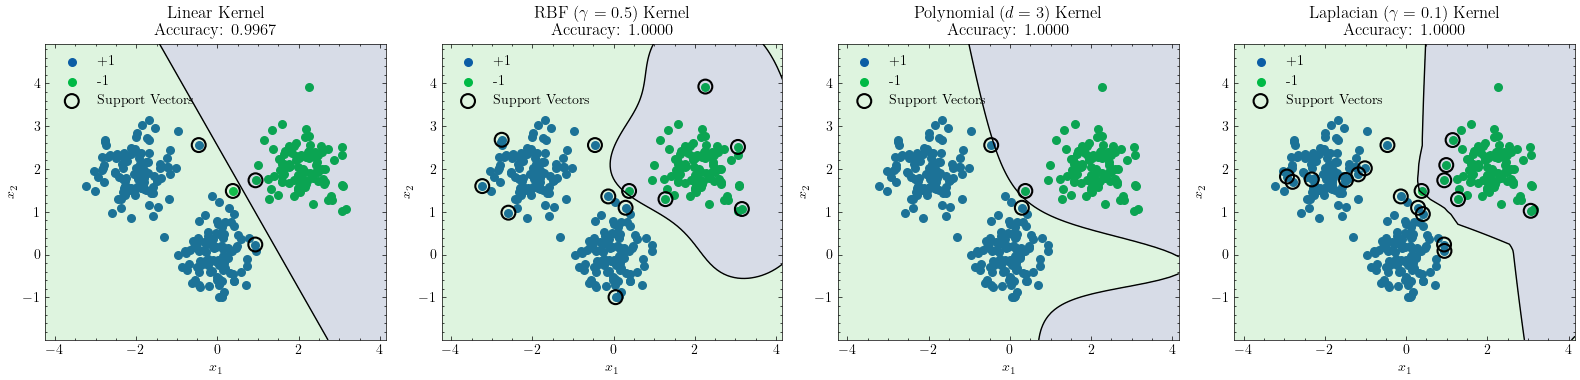

In [21]:
# Compare different kernels on a non-linear dataset
X_nl, y_nl = make_nonlinear_data(n=100, random_state=42)

# Create and compare models with different kernels
kernels = {
    "Linear": linear_kernel,
    "RBF ($\\gamma=0.5$)": make_rbf_kernel(gamma=0.5),
    "Polynomial ($d=3$)": make_polynomial_kernel(degree=3, coef0=0.1), 
    "Laplacian ($\\gamma=0.1$)": make_laplacian_kernel(gamma=0.1)
}

plt.figure(figsize=(16, 4))
for i, (name, kernel) in enumerate(kernels.items()):
    model = DualSVM(C=10.0, kernel=kernel, max_iter=max_iter, tol=1e-12, use_line_search = True, bb_steps=True, verbose=True)
    model.fit(X_nl, y_nl)
    acc = model.score(X_nl, y_nl)
    
    plt.subplot(1, 4, i+1)
    plt.title(f"{name} Kernel\nAccuracy: {acc:.4f}")
    
    # Plot data points
    plt.scatter(X_nl[y_nl==+1,0], X_nl[y_nl==+1,1], label="+1", s=30)
    plt.scatter(X_nl[y_nl==-1,0], X_nl[y_nl==-1,1], label="-1", s=30)
    
    # Create mesh and predict
    x_min, x_max = X_nl[:,0].min()-1, X_nl[:,0].max()+1
    y_min, y_max = X_nl[:,1].min()-1, X_nl[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary
    plt.contour(XX, YY, Z, levels=[0], colors='k')
    plt.contourf(XX, YY, Z, levels=[-1e9, 0, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X_nl[sv_indices, 0], X_nl[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5,
                   label="Support Vectors")
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.savefig("../figures/svm_kernels_comparison.png", dpi=300)
plt.tight_layout()
plt.show()

Dataset shape: (569, 30)
Number of features: 30
Class distribution: [212 357]

Results on Breast Cancer dataset:
------------------------------------------------------------
Kernel          | C     | Train Accuracy  | Test Accuracy  
------------------------------------------------------------
Linear          | 0.1   | 0.9824          | 0.9825         
Linear          | 1.0   | 0.9868          | 0.9561         
Linear          | 10.0  | 0.5077          | 0.5175         
RBF (gamma=0.01) | 0.1   | 0.9516          | 0.9649         
RBF (gamma=0.01) | 1.0   | 0.9758          | 0.9649         
RBF (gamma=0.01) | 10.0  | 0.9912          | 0.9825         
Poly (d=2)      | 0.1   | 0.7780          | 0.7719         
Poly (d=2)      | 1.0   | 0.7780          | 0.7719         
Poly (d=2)      | 10.0  | 0.7780          | 0.7719         
Lapl (gamma=0.1) | 0.1   | 0.9538          | 0.9561         
Lapl (gamma=0.1) | 1.0   | 0.9934          | 0.9649         
Lapl (gamma=0.1) | 10.0  | 1.0000       

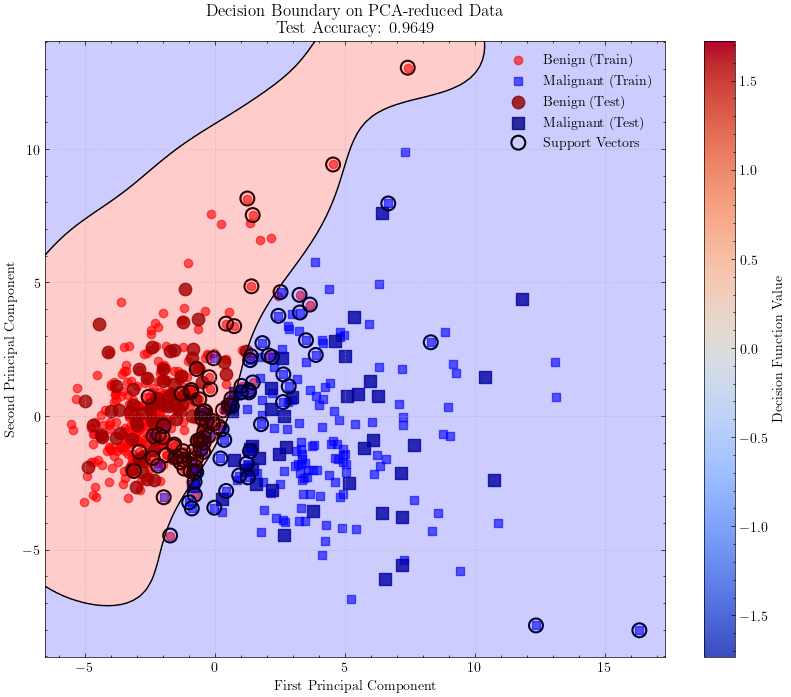


Feature importance (PCA components):
Principal Component 1 (Explains 43.25% of variance)
  mean concavity: 0.2580
  mean concave points: 0.2565
  worst concave points: 0.2491
  mean compactness: 0.2385
  worst perimeter: 0.2320
Principal Component 2 (Explains 19.73% of variance)
  mean fractal dimension: 0.3623
  fractal dimension error: 0.2959
  worst fractal dimension: 0.2666
  compactness error: 0.2455
  mean radius: -0.2399


In [9]:
# Let's also test a real dataset from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and preprocess breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = 2 * cancer.target - 1  # Convert to {-1, 1}

# Scale features
scaler = StandardScaler()
X_cancer = scaler.fit_transform(X_cancer)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X_cancer.shape}")
print(f"Number of features: {X_cancer.shape[1]}")
print(f"Class distribution: {np.bincount(cancer.target)}")

# Try different kernels on this real dataset
kernels = {
    "Linear": linear_kernel,
    "RBF (gamma=0.01)": make_rbf_kernel(gamma=0.01),
    "Poly (d=2)": make_polynomial_kernel(degree=2, coef0=0.01),
    "Lapl (gamma=0.1)": make_laplacian_kernel(gamma=0.1)
}

# Create a results table
print("\nResults on Breast Cancer dataset:")
print("-" * 60)
print(f"{'Kernel':<15} | {'C':<5} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 60)

for name, kernel in kernels.items():
    for C in [0.1, 1.0, 10.0]:
        model = DualSVM(C=C, kernel=kernel, max_iter=max_iter, tol=1e-12, use_line_search = True, bb_steps=True, verbose=False)
        model.fit(X_train, y_train)
        
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        
        print(f"{name:<15} | {C:<5.1f} | {train_acc:<15.4f} | {test_acc:<15.4f}")

print("-" * 60)

# Plot decision boundary for the best performing model using PCA for visualization
from sklearn.decomposition import PCA

# Train the best model on the full dataset
best_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.01), max_iter=1000)
best_model.fit(X_train, y_train)

# Use PCA to reduce the data to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Create a figure
plt.figure(figsize=(10, 8))
plt.title(f"PCA Visualization of Breast Cancer Dataset\nRBF Kernel ($\\gamma=0.01$), $C=1.0$, Test Accuracy: {best_model.score(X_test, y_test):.4f}")

# Plot the data points
plt.scatter(X_train_2d[y_train==+1, 0], X_train_2d[y_train==+1, 1], c='r', marker='o', alpha=0.6, label="Benign (Train)")
plt.scatter(X_train_2d[y_train==-1, 0], X_train_2d[y_train==-1, 1], c='b', marker='s', alpha=0.6, label="Malignant (Train)")
plt.scatter(X_test_2d[y_test==+1, 0], X_test_2d[y_test==+1, 1], c='darkred', marker='o', alpha=0.8, s=80, label="Benign (Test)")
plt.scatter(X_test_2d[y_test==-1, 0], X_test_2d[y_test==-1, 1], c='darkblue', marker='s', alpha=0.8, s=80, label="Malignant (Test)")

# Get support vectors in original space and project to 2D
sv_indices = best_model.get_support_vectors()
if len(sv_indices) > 0:
    plt.scatter(X_train_2d[sv_indices, 0], X_train_2d[sv_indices, 1], s=100, 
               facecolors='none', edgecolors='k', linewidths=1.5,
               label="Support Vectors")

# Create a mesh grid for the decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                    np.linspace(y_min, y_max, 100))

# This is a workaround as we can't directly visualize the decision boundary in 2D PCA space
# We'll train a new SVM model on the 2D PCA data just for visualization
viz_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.1), max_iter=1000)
viz_model.fit(X_train_2d, y_train)
Z = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contour(xx, yy, Z, levels=[0], colors='k')
contourf = plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], alpha=0.2, colors=['blue', 'red'])

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.5)

# Create a properly initialized ScalarMappable for the colorbar
norm = plt.Normalize(vmin=Z.min(), vmax=Z.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])  # You need to set an array for the ScalarMappable
plt.gcf().colorbar(sm, ax=plt.gca(), label='Decision Function Value')
plt.title(f"Decision Boundary on PCA-reduced Data\nTest Accuracy: {best_model.score(X_test, y_test):.4f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("../figures/breast_cancer_pca.png", dpi=300)
plt.show()

# Print feature importance based on PCA
print("\nFeature importance (PCA components):")
feature_names = cancer.feature_names
for i, (eigen_val, eigen_vec) in enumerate(zip(pca.explained_variance_ratio_, pca.components_)):
    if i < 2:  # Only show first two components
        print(f"Principal Component {i+1} (Explains {eigen_val*100:.2f}% of variance)")
        # Get the top 5 features contributing to this component
        indices = np.argsort(np.abs(eigen_vec))[-5:][::-1]
        for idx in indices:
            print(f"  {feature_names[idx]}: {eigen_vec[idx]:.4f}")

# Convergence Analysis

This section demonstrates how to analyze and visualize convergence behavior of our SVM optimization algorithms using the new functions added to `utils.py`.

In [10]:
# Create a small dataset for convergence analysis demonstration
X_conv, y_conv = make_toy_data(n=50, random_state=21)

# Train different models and track their convergence
# First with default parameters
print("Training a dual SVM for convergence analysis...")
model_default = DualSVM(C=1.0, max_iter=500, tol=1e-12, verbose=True)
model_default.fit(X_conv, y_conv)

# Then with BB steps enabled
print("\nTraining with Barzilai-Borwein steps...")
model_bb = DualSVM(C=1.0, max_iter=500, tol=1e-12, bb_steps=True, verbose=True)
model_bb.fit(X_conv, y_conv)

# Then with line search enabled
print("\nTraining with line search...")
model_ls = DualSVM(C=1.0, max_iter=500, tol=1e-12, use_line_search=True, verbose=True)
model_ls.fit(X_conv, y_conv)

# Create history dictionaries for each model
default_history = {'objective': model_default.obj_history}
bb_history = {'objective': model_bb.obj_history}
ls_history = {'objective': model_ls.obj_history}

# Add more metrics if available in your model implementation
if hasattr(model_default, 'grad_norm_history'):
    default_history['grad_norm'] = model_default.grad_norm_history
    bb_history['grad_norm'] = model_bb.grad_norm_history
    ls_history['grad_norm'] = model_ls.grad_norm_history

if hasattr(model_default, 'step_size_history'):
    default_history['step_size'] = model_default.step_size_history
    bb_history['step_size'] = model_bb.step_size_history
    ls_history['step_size'] = model_ls.step_size_history

if hasattr(model_default, 'alpha_diff_history'):
    default_history['alpha_diff'] = model_default.alpha_diff_history
    bb_history['alpha_diff'] = model_bb.alpha_diff_history
    ls_history['alpha_diff'] = model_ls.alpha_diff_history

Training a dual SVM for convergence analysis...
Iteration 0: obj=-0.1221, ||g||=7.0711, step=0.0049
Iteration 100: obj=-0.5000, ||g||=10.3620, step=0.3935

Training with Barzilai-Borwein steps...
Iteration 0: obj=-0.1221, ||g||=7.0711, step=0.0049
Iteration 100: obj=-0.5000, ||g||=10.3620, step=0.3935

Training with line search...
Iteration 0: obj=-0.1221, ||g||=7.0711, step=0.0049
Iteration 100: obj=-0.5000, ||g||=10.3620, step=0.3935


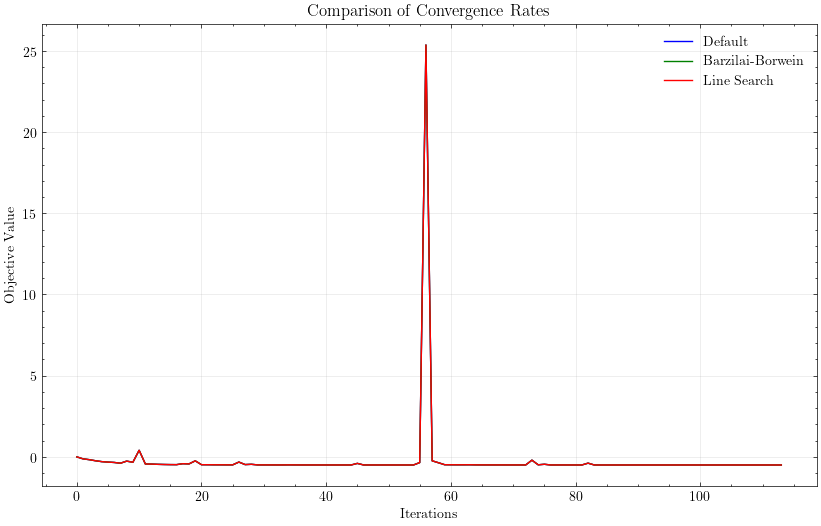

In [11]:
# Plot convergence of objective function for all methods
plt.figure(figsize=(10, 6))
plt.plot(default_history['objective'], 'b-', label='Default')
plt.plot(bb_history['objective'], 'g-', label='Barzilai-Borwein')
plt.plot(ls_history['objective'], 'r-', label='Line Search')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Comparison of Convergence Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../figures/convergence_comparison.png', dpi=200)
plt.show()

Detailed convergence plots for Barzilai-Borwein method:


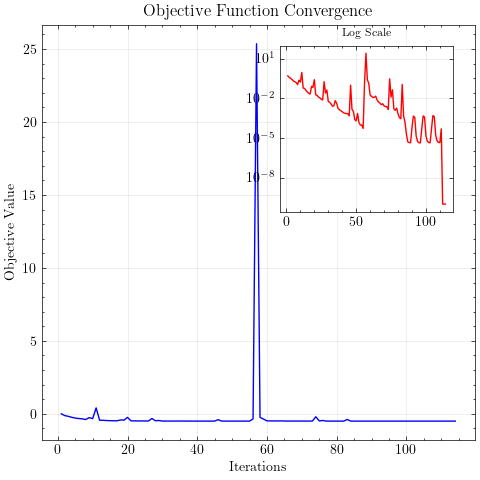

In [12]:
# Use the new plot_convergence function for detailed analysis of the BB method
print("Detailed convergence plots for Barzilai-Borwein method:")
fig, axes = plot_convergence(bb_history, save_path='../figures/bb_convergence_plots.png')

Convergence rate analysis for Barzilai-Borwein method:


/Users/saether/Library/CloudStorage/OneDrive-NTNU/Skole/Fysikk og matematikk - Master/3. År/6. semester/Optimization 1/exercises/project/svm/utils.py:523: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Average linear convergence rate: 42.031907
This suggests that the error decreases by a factor of approximately 42.031907 per iteration
Average quadratic convergence coefficient: 9.031381e+05
Estimated optimal objective value: -0.500000


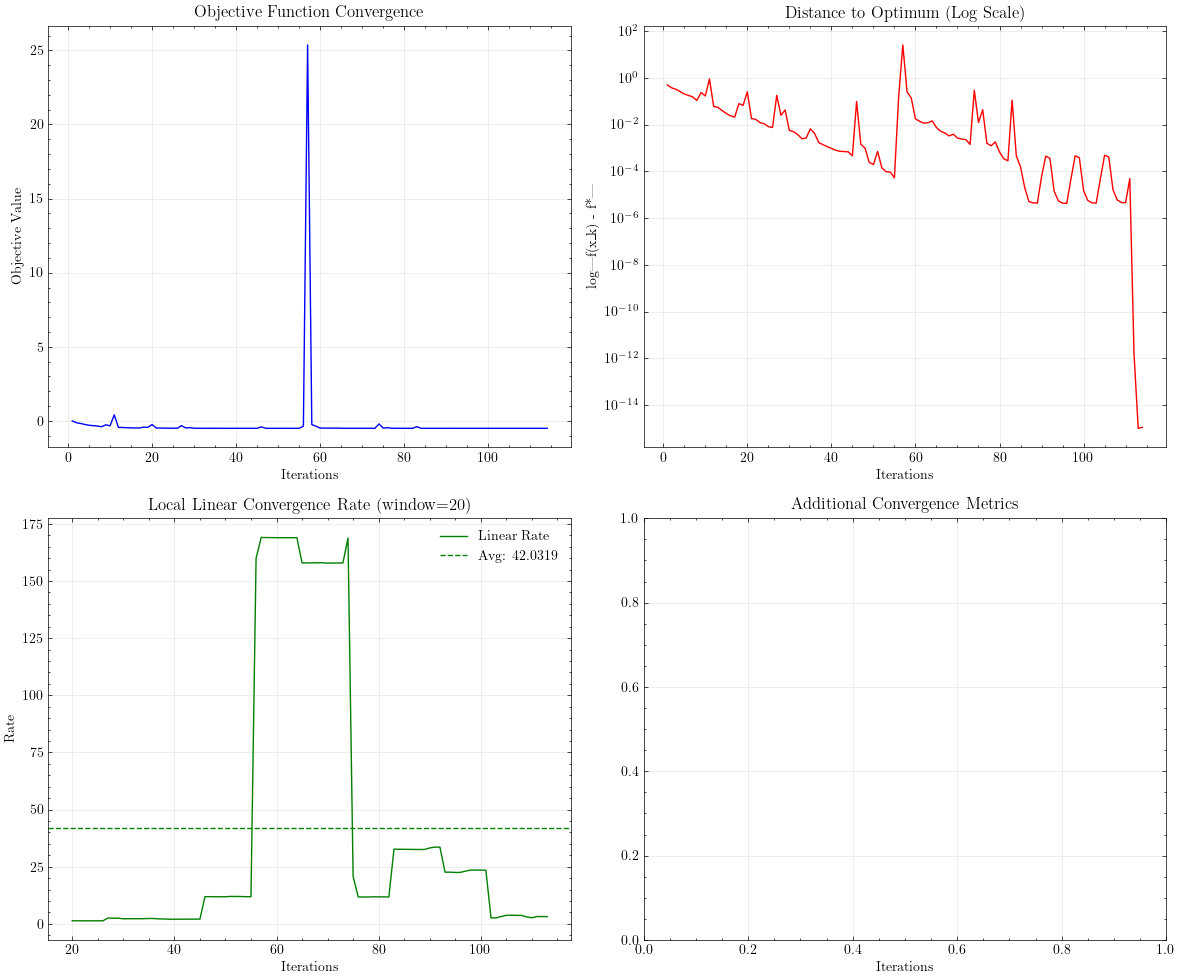

In [13]:
# Use the analyze_convergence function for a more in-depth analysis
print("Convergence rate analysis for Barzilai-Borwein method:")
results = analyze_convergence(bb_history, window_size=20, save_path='../figures/bb_convergence_analysis.png')

# Print key convergence metrics
if 'avg_linear_rate' in results:
    print(f"Average linear convergence rate: {results['avg_linear_rate']:.6f}")
    print(f"This suggests that the error decreases by a factor of approximately {results['avg_linear_rate']:.6f} per iteration")

if 'avg_quadratic_rate' in results:
    print(f"Average quadratic convergence coefficient: {results['avg_quadratic_rate']:.6e}")

print(f"Estimated optimal objective value: {results['optimal_value_est']:.6f}")

## Convergence Analysis for Different Kernels

Let's also analyze how convergence behavior changes with different kernel functions.

In [14]:
# Compare convergence for different kernels on the non-linear dataset
X_nl, y_nl = make_nonlinear_data(n=100, random_state=42)

# Define kernels to compare
kernels = {
    "Linear": linear_kernel,
    "RBF": make_rbf_kernel(gamma=0.5),
    "Polynomial": make_polynomial_kernel(degree=3, coef0=0.1),
    "Laplacian": make_laplacian_kernel(gamma=0.5)
}

# Train models and collect histories
kernel_histories = {}
for name, kernel in kernels.items():
    print(f"\nTraining with {name} kernel...")
    model = DualSVM(C=1.0, kernel=kernel, max_iter=250, tol=1e-12, 
                   bb_steps=True, use_line_search=True, verbose=False)
    model.fit(X_nl, y_nl)
    kernel_histories[name] = {'objective': model.obj_history}

    # Add additional metrics if available
    if hasattr(model, 'grad_norm_history'):
        kernel_histories[name]['grad_norm'] = model.grad_norm_history
    if hasattr(model, 'step_size_history'):
        kernel_histories[name]['step_size'] = model.step_size_history
    if hasattr(model, 'alpha_diff_history'):
        kernel_histories[name]['alpha_diff'] = model.alpha_diff_history


Training with Linear kernel...

Training with RBF kernel...

Training with Polynomial kernel...

Training with Laplacian kernel...


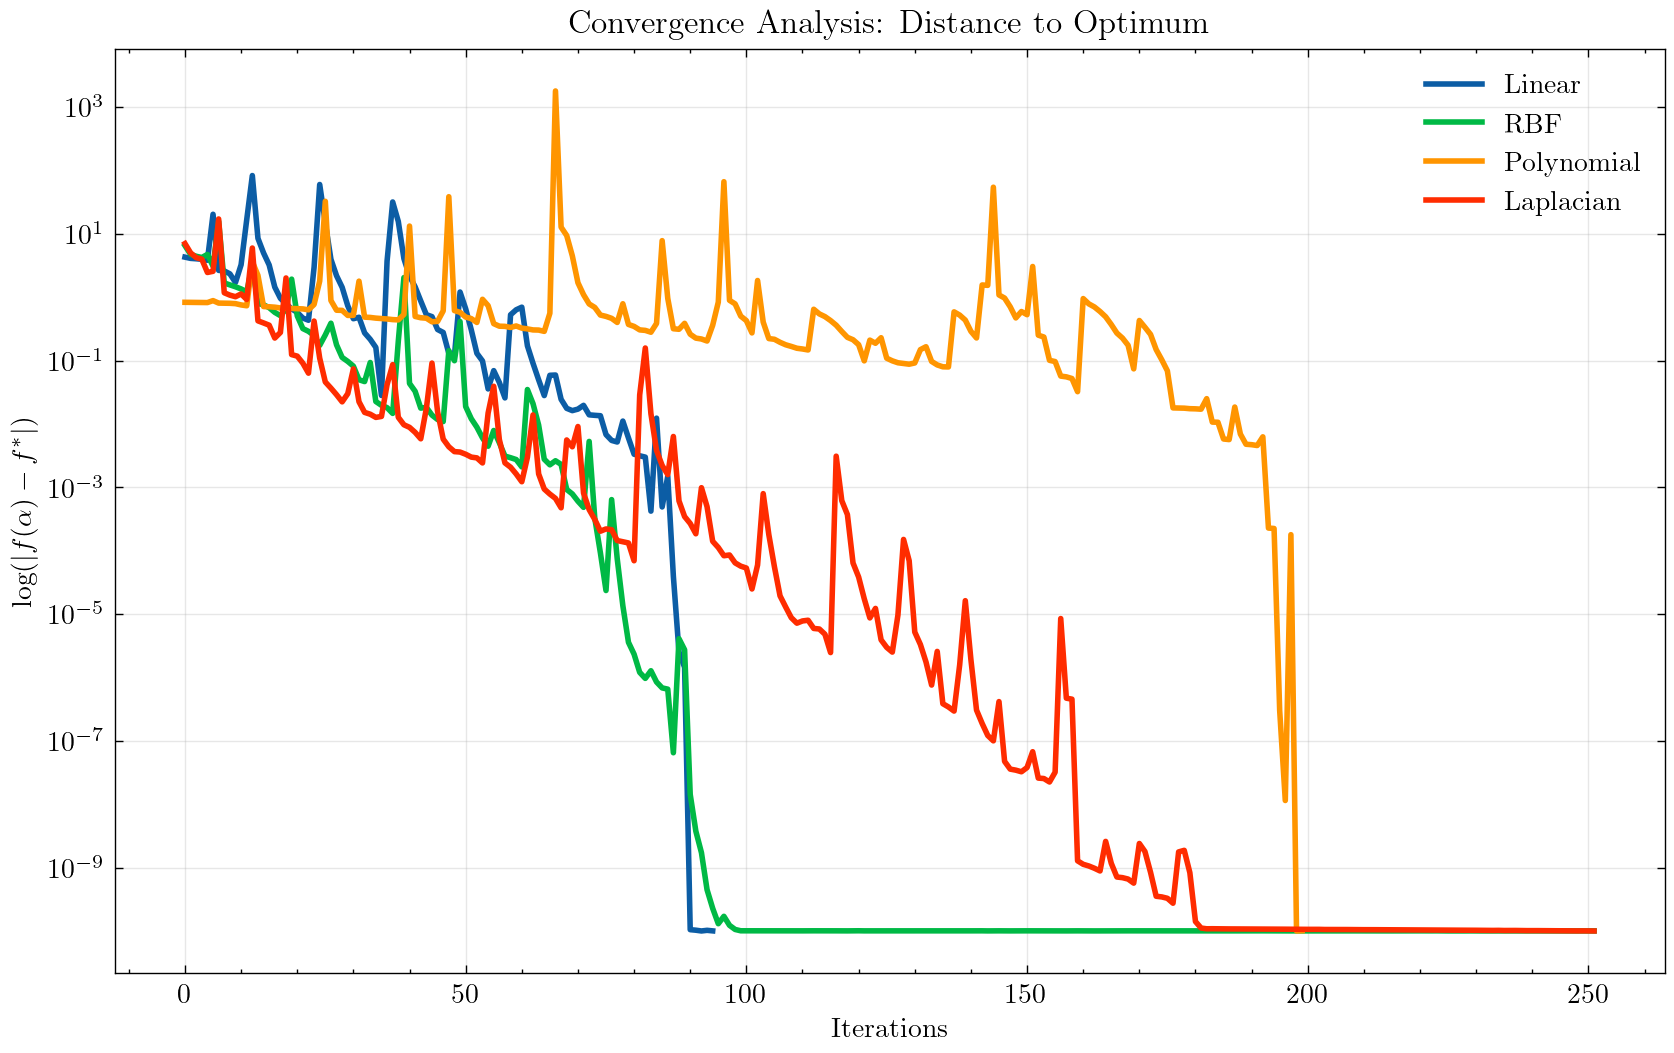

In [15]:
# Plot log-scale convergence for all kernels
plt.figure(figsize=(10, 6), dpi=200)

# Plot log-scale convergence
for name, history in kernel_histories.items():
    obj_values = history['objective']
    opt_val = min(obj_values)
    # Add small epsilon to avoid log(0)
    plt.semilogy(range(len(obj_values)), 
                 [abs(v - opt_val) + 1e-10 for v in obj_values], 
                 label=name, 
                 linewidth=2)

plt.title('Convergence Analysis: Distance to Optimum')
plt.grid(True, alpha=0.3)
plt.xlabel(r'$\text{Iterations}$')
plt.ylabel(r'$\log(|f(\alpha) - f^*|)$')
plt.legend(loc='best')

# Save figure with high DPI
plt.savefig('../figures/kernel_convergence_comparison.png', 
            dpi=300, 
            bbox_inches='tight')
plt.show()
